# Data Consolidation — MIMIC-IV-Ext

**Input:** `s3://ed-triage-capstone-group7/Dataset/`  
**Output:** `s3://ed-triage-capstone-group7/Data_Output/consolidated_dataset_PMH_v2.csv`  
**Schema:** 22 columns × 9,149 rows  

## Section 1 — Imports & Paths

In [17]:
import os
import re
import io
import boto3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

# AWS config — matches the pattern used in generate_embeddings.py / upload_to_pinecone.py
# Credentials live in ~/.aws/credentials under the "ed-triage" named profile
AWS_PROFILE = os.getenv("AWS_PROFILE", "ed-triage")
AWS_REGION  = os.getenv("AWS_REGION",  "us-east-1")
S3_BUCKET   = os.getenv("S3_BUCKET",   "ed-triage-capstone-group7")
S3_PREFIX   = "Dataset"

# Shared boto3 session — all S3 reads go through this
session  = boto3.Session(profile_name=AWS_PROFILE, region_name=AWS_REGION)
s3       = session.client("s3")

print(f"AWS profile : {AWS_PROFILE}")
print(f"S3 bucket   : s3://{S3_BUCKET}/{S3_PREFIX}/")


def read_csv_from_s3(filename: str) -> pd.DataFrame:
    """Download a CSV from S3 and return it as a DataFrame."""
    key = f"{S3_PREFIX}/{filename}"
    obj = s3.get_object(Bucket=S3_BUCKET, Key=key)
    return pd.read_csv(io.BytesIO(obj["Body"].read()))


AWS profile : ed-triage
S3 bucket   : s3://ed-triage-capstone-group7/Dataset/


## Section 2 — Load All Source Files
 
**Important:** These files contain multi-line quoted text fields. Never pass `quoting=` or `lineterminator=` — pandas default quoting (QUOTE_MINIMAL) handles them correctly.

In [18]:
# --- clinical_data.csv ---
df_clinical = read_csv_from_s3("clinical_data.csv")
print("=== clinical_data.csv ===")
print(f"Shape: {df_clinical.shape}")
print(df_clinical.dtypes)
print()

# --- vital_signs.csv ---
df_vitals = read_csv_from_s3("vital_signs.csv")
print("=== vital_signs.csv ===")
print(f"Shape: {df_vitals.shape}")
print(df_vitals.dtypes)
print()

# --- patient_demographics.csv ---
df_demo = read_csv_from_s3("patient_demographics.csv")
print("=== patient_demographics.csv ===")
print(f"Shape: {df_demo.shape}")
print(df_demo.dtypes)
print()

# --- initial_assessment_info.csv ---
df_assess = read_csv_from_s3("initial_assessment_info.csv")
print("=== initial_assessment_info.csv ===")
print(f"Shape: {df_assess.shape}")
print(df_assess.dtypes)
print()

# --- specialty_referral.csv ---
df_specialty = read_csv_from_s3("specialty_referral.csv")
print("=== specialty_referral.csv ===")
print(f"Shape: {df_specialty.shape}")
print(df_specialty.dtypes)


=== clinical_data.csv ===
Shape: (9149, 8)
stay_id                 int64
text                   object
HPI                    object
tests                  object
past_medication        object
diagnosis              object
primary_diagnosis      object
secondary_diagnosis    object
dtype: object

=== vital_signs.csv ===
Shape: (9149, 4)
stay_id            int64
subject_id         int64
hadm_id            int64
initial_vitals    object
dtype: object

=== patient_demographics.csv ===
Shape: (9149, 2)
stay_id          int64
patient_info    object
dtype: object

=== initial_assessment_info.csv ===
Shape: (9149, 9)
stay_id               int64
triage                int64
pain                 object
chiefcomplaint       object
arrival_transport    object
disposition          object
icd_code             object
icd_title            object
icd_version           int64
dtype: object

=== specialty_referral.csv ===
Shape: (2200, 5)
stay_id            int64
HPI               object
patient_info     

## Section 3 — Enhanced EDA

Deep-dive analysis per column type: parsed distributions, class imbalances, text length profiles, cross-variable relationships, and outlier detection. Charts are inline. Source dataframes (`df_vitals`, `df_clinical`, `df_demo`, `df_assess`, `df_specialty`) must be loaded before running these cells.

In [19]:
# ── 3.1  initial_vitals — parse structured values from text strings ──────────
import re

VITAL_PATTERNS = {
    "Temperature":   r"Temperature:\s*([\d.]+)",
    "Heart Rate":    r"Heartrate:\s*([\d.]+)",
    "Resp Rate":     r"resprate:\s*([\d.]+)",
    "O2 Sat (%)":   r"o2sat:\s*([\d.]+)",
    "SBP":          r"sbp:\s*([\d.]+)",
    "DBP":          r"dbp:\s*([\d.]+)",
}

def parse_vitals(text):
    row = {}
    for name, pattern in VITAL_PATTERNS.items():
        m = re.search(pattern, str(text), re.IGNORECASE)
        row[name] = float(m.group(1)) if m else None
    return row

df_vitals_parsed = df_vitals["initial_vitals"].apply(parse_vitals).apply(pd.Series)
df_vitals_parsed.insert(0, "stay_id", df_vitals["stay_id"])

print("Parsed vitals shape:", df_vitals_parsed.shape)
print("\nNull counts per vital field:")
print(df_vitals_parsed.drop(columns="stay_id").isna().sum().to_string())
print("\nDescriptive stats:")
print(df_vitals_parsed.drop(columns="stay_id").describe().round(2))

Parsed vitals shape: (9149, 7)

Null counts per vital field:
Temperature    581
Heart Rate     397
Resp Rate      513
O2 Sat (%)     484
SBP            408
DBP            425

Descriptive stats:
       Temperature  Heart Rate  Resp Rate  O2 Sat (%)       SBP      DBP
count      8568.00     8752.00    8636.00     8665.00   8741.00  8724.00
mean         98.11       85.41      17.55       98.05    136.65    78.04
std           2.46       18.13       2.37        3.05    211.06    98.69
min           6.80        9.00       6.00        9.00     10.00     4.00
25%          97.60       73.00      16.00       97.00    119.00    66.00
50%          98.10       84.00      18.00       99.00    133.00    76.00
75%          98.60       96.00      18.00      100.00    148.00    86.00
max         106.60      190.00      48.00      100.00  19734.00  6698.00


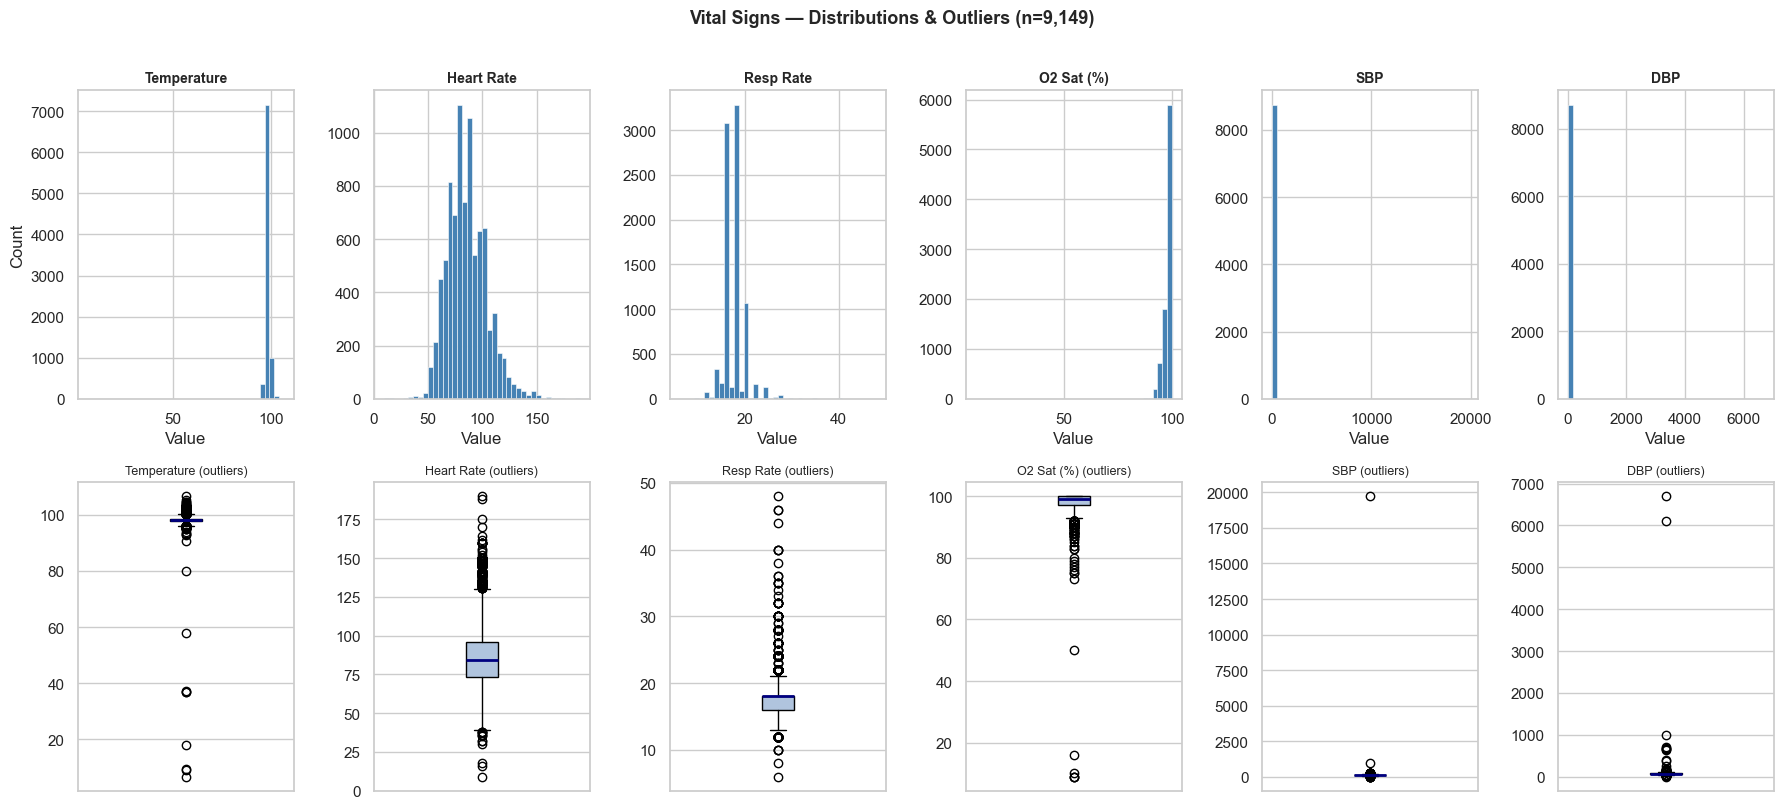

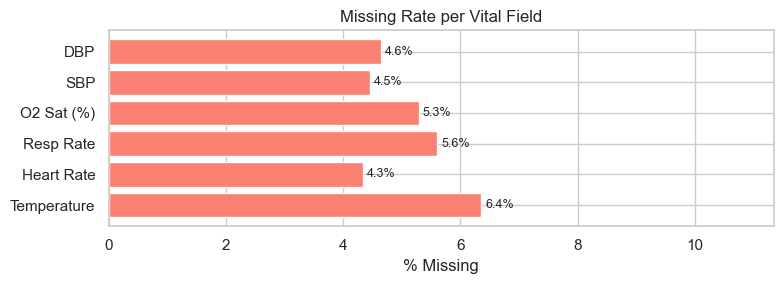

In [20]:
# ── 3.2  Vital Signs — histograms and boxplots ───────────────────────────────
vital_cols = list(VITAL_PATTERNS.keys())
fig, axes = plt.subplots(2, len(vital_cols), figsize=(18, 8))

for i, col in enumerate(vital_cols):
    data = df_vitals_parsed[col].dropna()
    # Histogram
    axes[0, i].hist(data, bins=40, color="steelblue", edgecolor="white", linewidth=0.4)
    axes[0, i].set_title(col, fontsize=10, fontweight="bold")
    axes[0, i].set_xlabel("Value")
    axes[0, i].set_ylabel("Count" if i == 0 else "")
    # Boxplot
    axes[1, i].boxplot(data, vert=True, patch_artist=True,
                       boxprops=dict(facecolor="lightsteelblue"),
                       medianprops=dict(color="navy", linewidth=2))
    axes[1, i].set_title(f"{col} (outliers)", fontsize=9)
    axes[1, i].set_xticks([])

fig.suptitle("Vital Signs — Distributions & Outliers (n=9,149)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Missing rate per vital
missing_pct = df_vitals_parsed[vital_cols].isna().mean() * 100
fig2, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(vital_cols, missing_pct, color="salmon")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax.set_xlabel("% Missing")
ax.set_title("Missing Rate per Vital Field")
ax.set_xlim(0, max(missing_pct.max() + 5, 5))
plt.tight_layout()
plt.show()

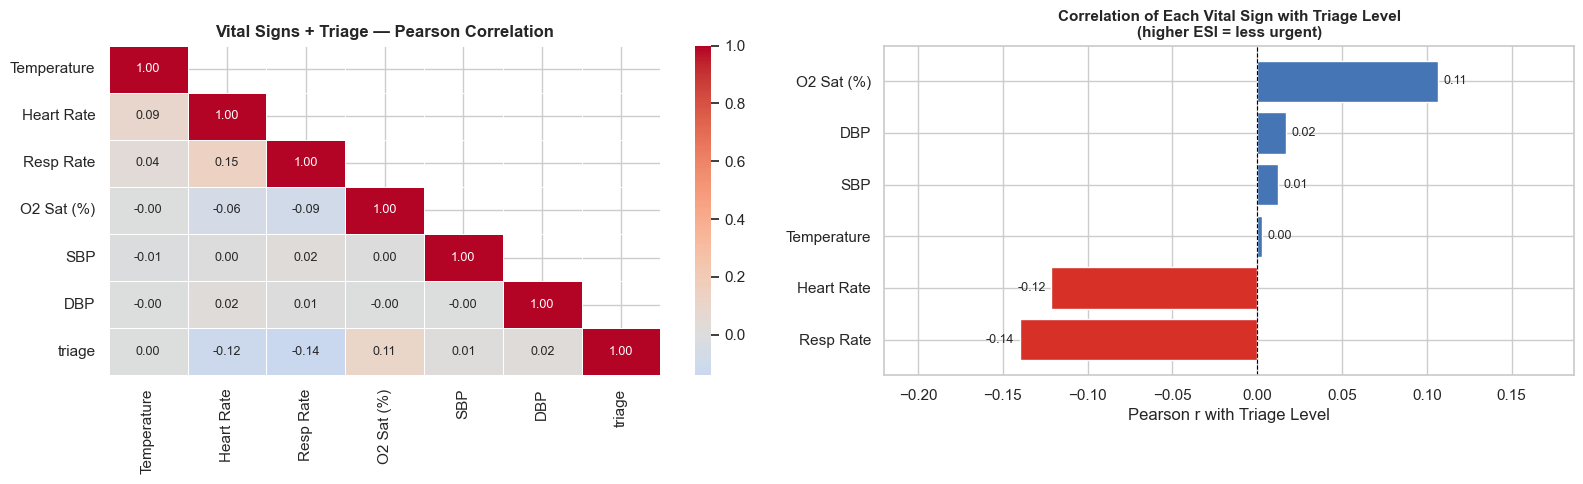

Correlation with Triage Level (sorted):
Resp Rate     -0.139829
Heart Rate    -0.121473
Temperature    0.002621
SBP            0.012405
DBP            0.016866
O2 Sat (%)     0.106774


In [21]:
# ── 3.3  Vital Signs — correlation with Triage Level ─────────────────────────
import numpy as np

# Merge parsed vitals with triage so we can include it in the correlation matrix
df_vitals_triage = df_vitals_parsed.merge(
    df_assess[["stay_id", "triage"]], on="stay_id", how="left"
)

# Correlation matrix including triage
corr_cols = vital_cols + ["triage"]
corr = df_vitals_triage[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: full heatmap with triage included ---
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask_upper, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=axes[0], annot_kws={"size": 9})
axes[0].set_title("Vital Signs + Triage — Pearson Correlation", fontsize=12, fontweight="bold")

# --- Right: bar chart of each vital's correlation with triage (sorted) ---
triage_corr = corr["triage"].drop("triage").sort_values()
colors = ["#d73027" if v < 0 else "#4575b4" for v in triage_corr]
bars = axes[1].barh(triage_corr.index, triage_corr.values, color=colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
axes[1].set_title("Correlation of Each Vital Sign with Triage Level\n(higher ESI = less urgent)", 
                   fontsize=11, fontweight="bold")
axes[1].set_xlabel("Pearson r with Triage Level")
axes[1].set_xlim(triage_corr.min() - 0.08, triage_corr.max() + 0.08)

plt.tight_layout()
plt.show()

print("Correlation with Triage Level (sorted):")
print(triage_corr.sort_values().to_string())

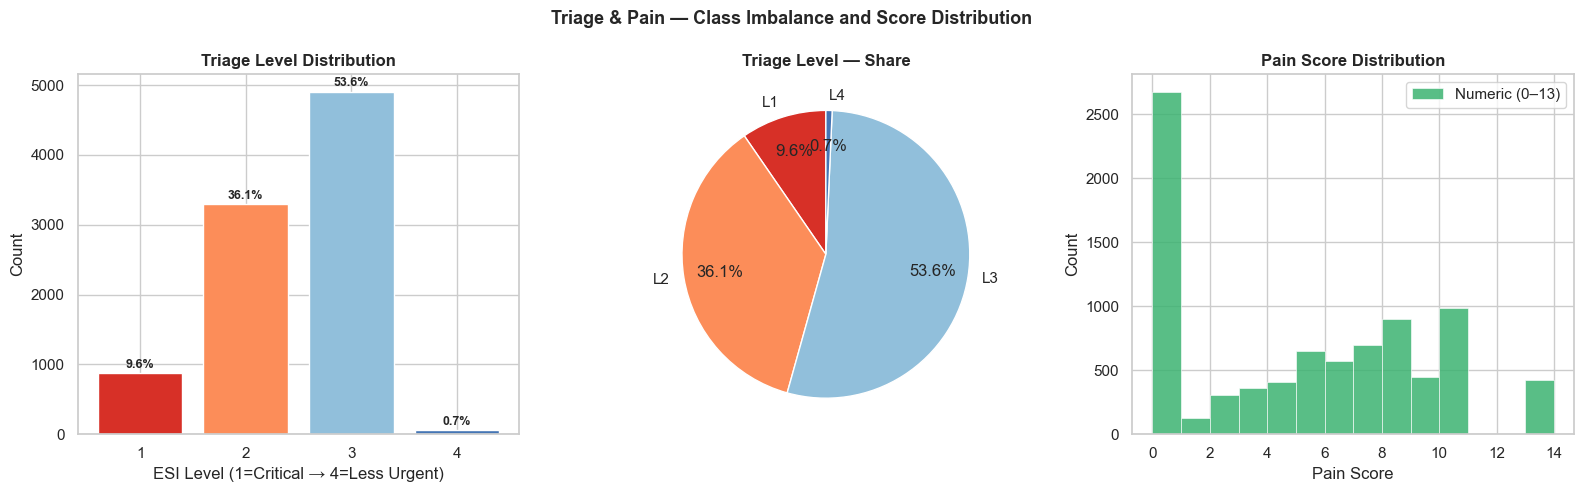

Non-numeric pain values (string-encoded):
pain
unable                 79
Critical               47
uta                    35
ua                     23
UTA                    21
critical                8
c                       7
UA                      6
unable                  5
prehosp                 5
o                       3
yes                     3
Unable                  3
5-6                     3
4-5                     3
6-7                     3
u/a                     3
8-9                     3
mild                    2
u                       2
2-3                     2
?                       2
alot                    2
Non-verbal              2
controlled              2
ett                     2
not too bad             2
pain                    2
crit                    2
+                       2
asleep                  1
Refusing                1
7-8                     1
Yes                     1
3-4                     1
uta                     1
crit             

In [22]:
# ── 3.4  Triage level + Pain score distributions ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Triage bar chart ---
triage_counts = df_assess["triage"].value_counts().sort_index()
triage_pct    = triage_counts / triage_counts.sum() * 100
bars = axes[0].bar(triage_counts.index.astype(str), triage_counts.values, color=["#d73027","#fc8d59","#91bfdb","#4575b4"])
for bar, pct in zip(bars, triage_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_title("Triage Level Distribution", fontweight="bold")
axes[0].set_xlabel("ESI Level (1=Critical → 4=Less Urgent)")
axes[0].set_ylabel("Count")

# --- Triage pie chart ---
axes[1].pie(triage_counts, labels=[f"L{l}" for l in triage_counts.index],
            autopct="%1.1f%%", colors=["#d73027","#fc8d59","#91bfdb","#4575b4"],
            startangle=90, pctdistance=0.75)
axes[1].set_title("Triage Level — Share", fontweight="bold")

# --- Pain: split numeric vs string-encoded ---
pain_raw = df_assess["pain"].copy()
pain_numeric = pd.to_numeric(pain_raw, errors="coerce")
pain_str_mask = pain_numeric.isna() & pain_raw.notna()

axes[2].hist(pain_numeric.dropna(), bins=range(0, 15), color="mediumseagreen",
             edgecolor="white", linewidth=0.5, alpha=0.85, label="Numeric (0–13)")
axes[2].set_title("Pain Score Distribution", fontweight="bold")
axes[2].set_xlabel("Pain Score")
axes[2].set_ylabel("Count")
axes[2].legend()

fig.suptitle("Triage & Pain — Class Imbalance and Score Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Print non-numeric pain values
print("Non-numeric pain values (string-encoded):")
print(pain_raw[pain_str_mask].value_counts(dropna=False).to_string())
print(f"\nTotal non-numeric pain entries: {pain_str_mask.sum()}")
print(f"Total pain nulls: {pain_numeric.isna().sum()} (includes string-encoded)")

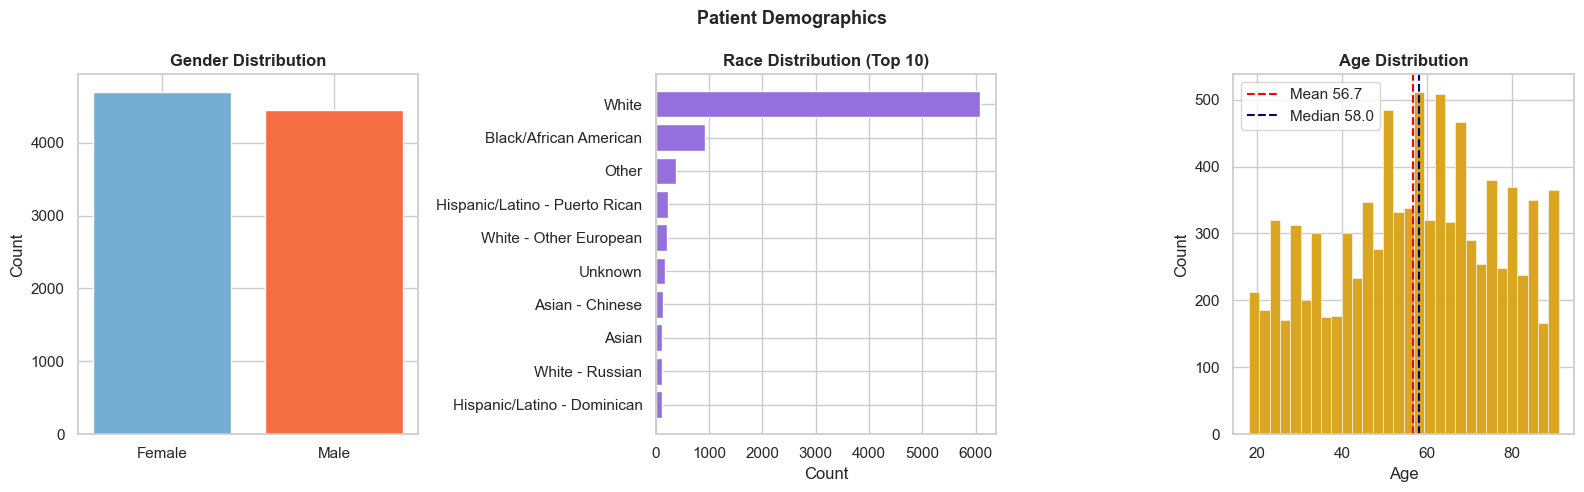

Age stats — min: 18, max: 91, mean: 56.7, std: 19.7


In [23]:
# ── 3.5  patient_info — parse Gender, Race, Age ──────────────────────────────
def parse_demographics(text):
    if not isinstance(text, str):
        return {"Gender": None, "Race": None, "Age": None}
    gender = re.search(r"Gender:\s*(\w+)", text, re.IGNORECASE)
    race   = re.search(r"Race:\s*([^,\n]+)", text, re.IGNORECASE)
    age    = re.search(r"Age:\s*(\d+)", text, re.IGNORECASE)
    return {
        "Gender": gender.group(1).strip().title() if gender else None,
        "Race":   race.group(1).strip().title() if race else None,
        "Age":    int(age.group(1)) if age else None,
    }

df_demo_parsed = df_demo["patient_info"].apply(parse_demographics).apply(pd.Series)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gender
gender_counts = df_demo_parsed["Gender"].value_counts(dropna=False)
axes[0].bar(gender_counts.index.astype(str), gender_counts.values, color=["#74add1","#f46d43","#abdda4"])
axes[0].set_title("Gender Distribution", fontweight="bold")
axes[0].set_ylabel("Count")

# Race (top 10)
race_counts = df_demo_parsed["Race"].value_counts(dropna=False).head(10)
axes[1].barh(race_counts.index.astype(str)[::-1], race_counts.values[::-1], color="mediumpurple")
axes[1].set_title("Race Distribution (Top 10)", fontweight="bold")
axes[1].set_xlabel("Count")

# Age histogram
ages = df_demo_parsed["Age"].dropna()
axes[2].hist(ages, bins=30, color="goldenrod", edgecolor="white", linewidth=0.4)
axes[2].axvline(ages.mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean {ages.mean():.1f}")
axes[2].axvline(ages.median(), color="navy", linestyle="--", linewidth=1.5, label=f"Median {ages.median():.1f}")
axes[2].set_title("Age Distribution", fontweight="bold")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Count")
axes[2].legend()

fig.suptitle("Patient Demographics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Age stats — min: {ages.min()}, max: {ages.max()}, mean: {ages.mean():.1f}, std: {ages.std():.1f}")

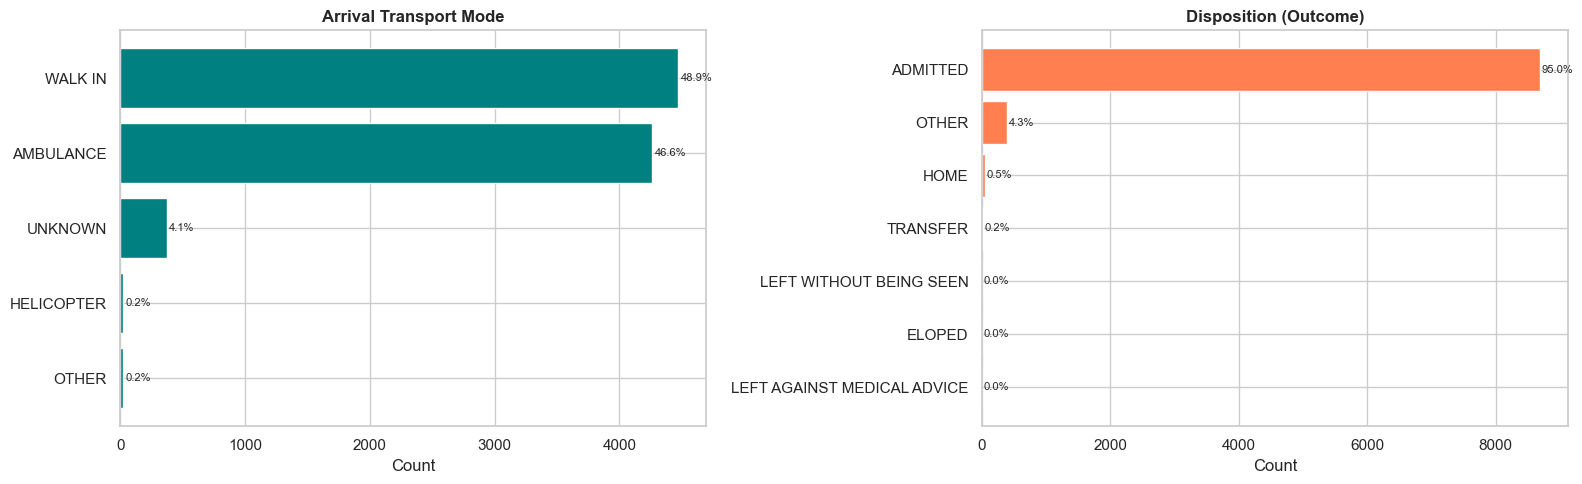

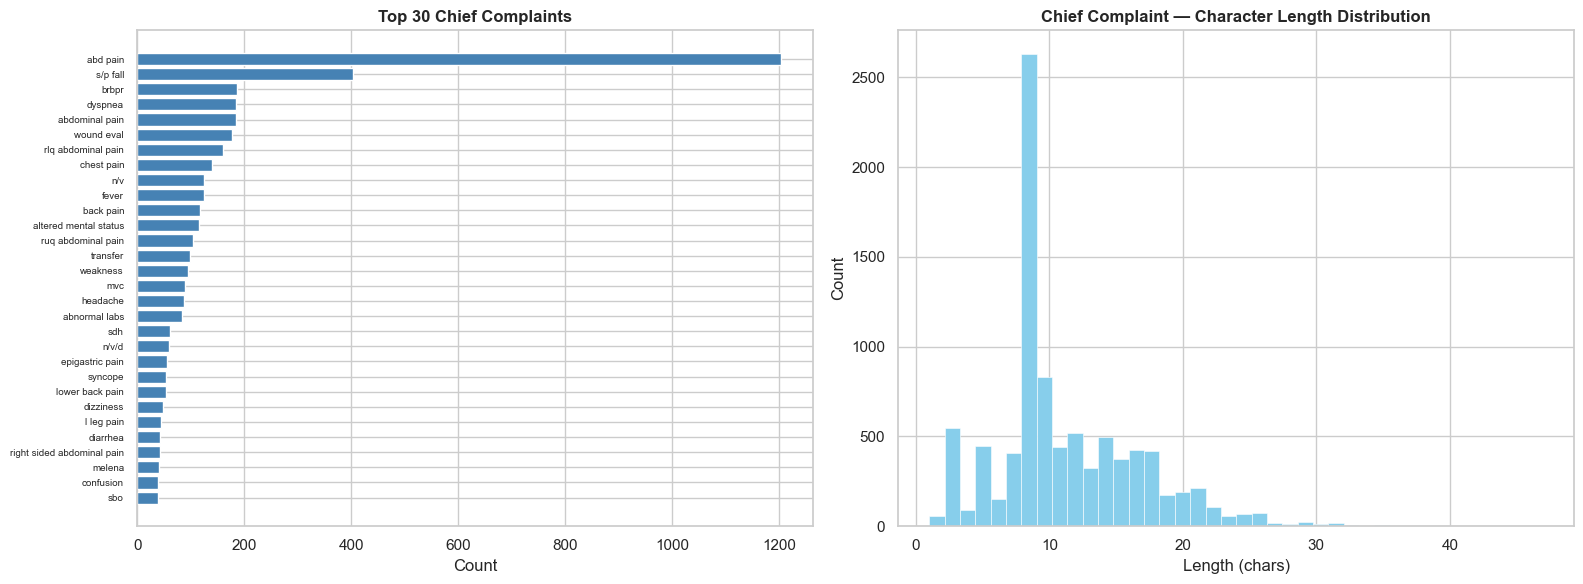

In [24]:
# ── 3.6  Categorical columns — chiefcomplaint, arrival_transport, disposition ─
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Arrival transport
transport = df_assess["arrival_transport"].value_counts(dropna=False)
axes[0].barh(transport.index.astype(str)[::-1], transport.values[::-1], color="teal")
for i, cnt in enumerate(transport.values[::-1]):
    pct = cnt / len(df_assess) * 100
    axes[0].text(cnt + 20, i, f"{pct:.1f}%", va="center", fontsize=8)
axes[0].set_title("Arrival Transport Mode", fontweight="bold")
axes[0].set_xlabel("Count")

# Disposition
disposition = df_assess["disposition"].value_counts(dropna=False)
axes[1].barh(disposition.index.astype(str)[::-1], disposition.values[::-1], color="coral")
for i, cnt in enumerate(disposition.values[::-1]):
    pct = cnt / len(df_assess) * 100
    axes[1].text(cnt + 20, i, f"{pct:.1f}%", va="center", fontsize=8)
axes[1].set_title("Disposition (Outcome)", fontweight="bold")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

# Chief complaint — top 30 + length distribution
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

top_cc = df_assess["chiefcomplaint"].str.lower().str.strip().value_counts().head(30)
axes2[0].barh(top_cc.index[::-1], top_cc.values[::-1], color="steelblue")
axes2[0].set_title("Top 30 Chief Complaints", fontweight="bold")
axes2[0].set_xlabel("Count")
axes2[0].tick_params(axis="y", labelsize=7)

cc_len = df_assess["chiefcomplaint"].dropna().str.len()
axes2[1].hist(cc_len, bins=40, color="skyblue", edgecolor="white", linewidth=0.4)
axes2[1].set_title("Chief Complaint — Character Length Distribution", fontweight="bold")
axes2[1].set_xlabel("Length (chars)")
axes2[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

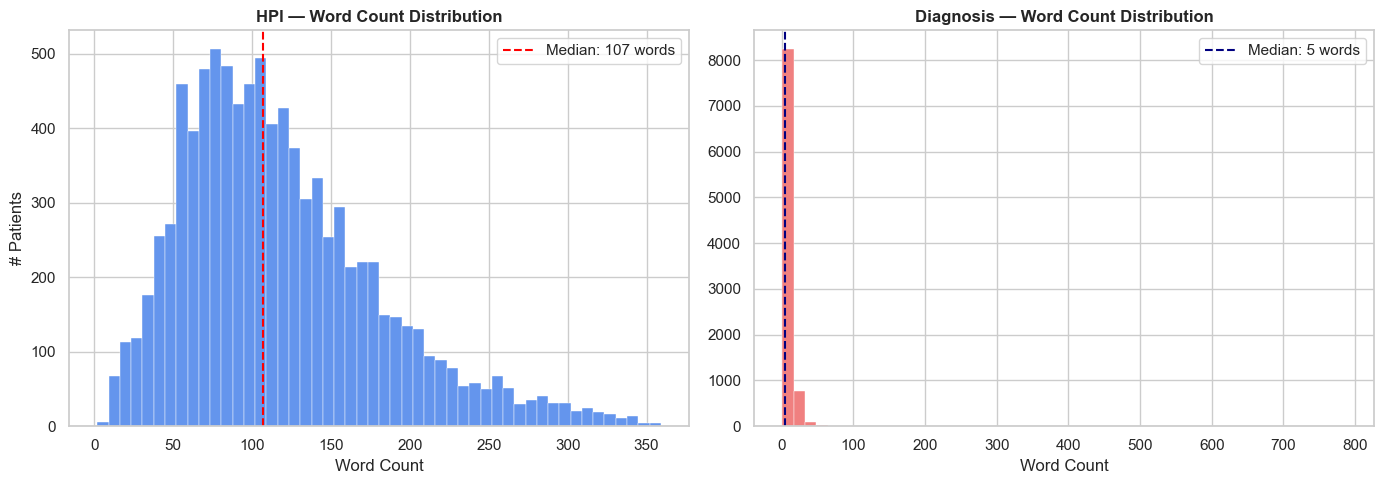

HPI — min: 0, median: 107, mean: 118, max: 359, zeros: 1
diagnosis — min: 0, median: 5, mean: 8, max: 787, zeros: 2


In [25]:
# ── 3.8  Text columns — HPI and diagnosis word-count distributions ────────────
def word_count(text):
    if not isinstance(text, str):
        return 0
    return len(text.split())

hpi_wc   = df_clinical["HPI"].apply(word_count)
diag_wc  = df_clinical["diagnosis"].apply(word_count)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(hpi_wc[hpi_wc > 0], bins=50, color="cornflowerblue", edgecolor="white", linewidth=0.3)
axes[0].axvline(hpi_wc.median(), color="red", linestyle="--", linewidth=1.5,
                label=f"Median: {hpi_wc.median():.0f} words")
axes[0].set_title("HPI — Word Count Distribution", fontweight="bold")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("# Patients")
axes[0].legend()

axes[1].hist(diag_wc[diag_wc > 0], bins=50, color="lightcoral", edgecolor="white", linewidth=0.3)
axes[1].axvline(diag_wc.median(), color="navy", linestyle="--", linewidth=1.5,
                label=f"Median: {diag_wc.median():.0f} words")
axes[1].set_title("Diagnosis — Word Count Distribution", fontweight="bold")
axes[1].set_xlabel("Word Count")
axes[1].legend()

plt.tight_layout()
plt.show()

for col, wc in [("HPI", hpi_wc), ("diagnosis", diag_wc)]:
    print(f"{col} — min: {wc.min()}, median: {wc.median():.0f}, mean: {wc.mean():.0f}, "
          f"max: {wc.max()}, zeros: {(wc == 0).sum()}")

Pain scores outside 0–10 excluded: 435 rows


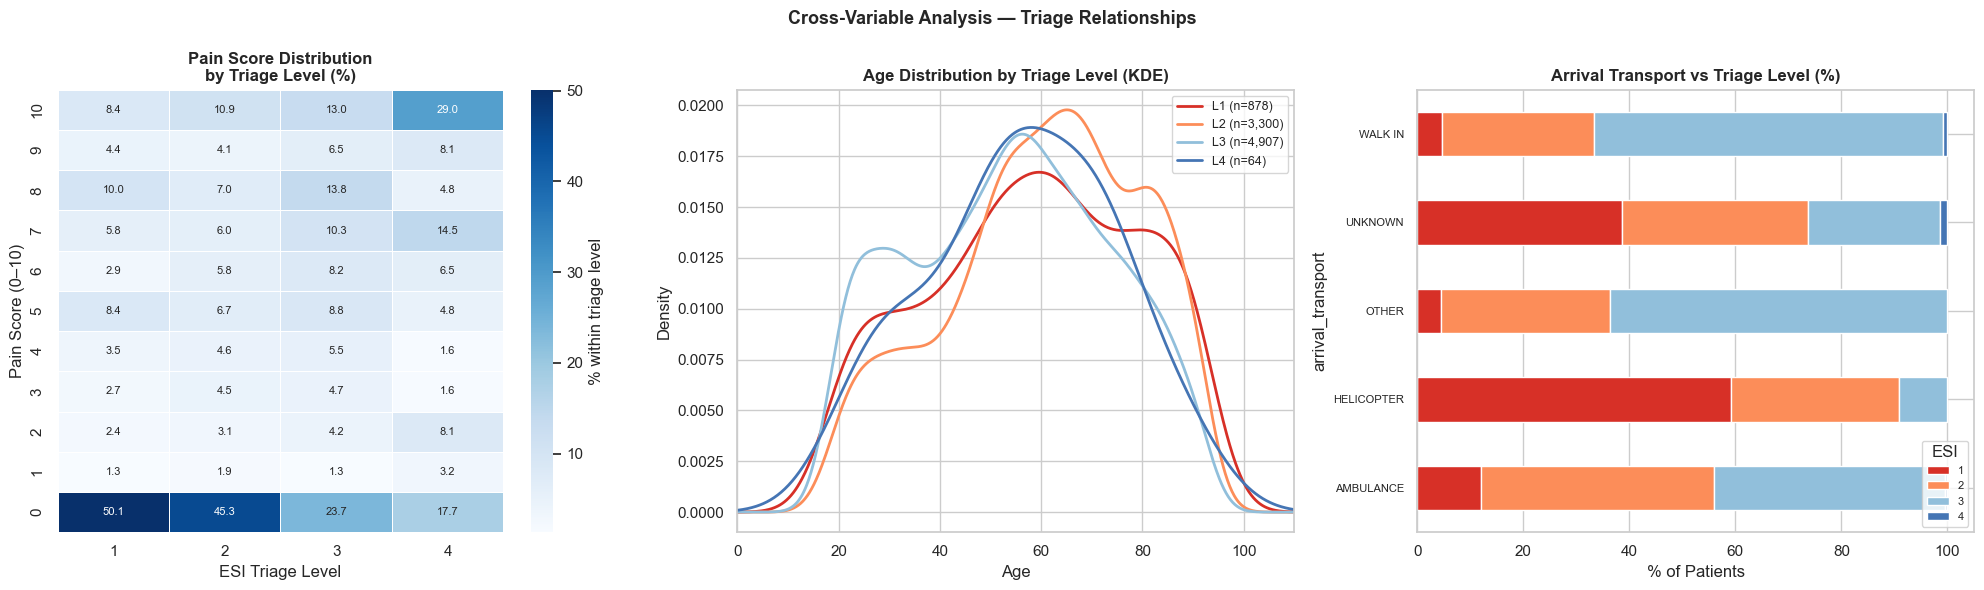

In [26]:
# ── 3.9  Cross-variable analysis — Triage vs Pain (heatmap), Age, Arrival Transport ─────
import re

def parse_demographics_xv(text):
    if not isinstance(text, str):
        return {"Gender": None, "Race": None, "Age": None}
    gender = re.search(r"Gender:\s*(\w+)", text, re.IGNORECASE)
    race   = re.search(r"Race:\s*([^,\n]+)", text, re.IGNORECASE)
    age    = re.search(r"Age:\s*(\d+)", text, re.IGNORECASE)
    return {
        "Gender": gender.group(1).strip().title() if gender else None,
        "Race":   race.group(1).strip().title() if race else None,
        "Age":    int(age.group(1)) if age else None,
    }

# Merge triage + parsed pain + parsed age for cross-analysis
df_cross = df_assess[["stay_id", "triage", "arrival_transport"]].copy()
df_cross["pain_numeric"] = pd.to_numeric(df_assess["pain"], errors="coerce")
df_cross = df_cross.merge(
    df_demo["stay_id"].to_frame().join(
        df_demo["patient_info"].apply(parse_demographics_xv).apply(pd.Series)
    ),
    on="stay_id", how="left"
)

# Limit pain to standard clinical scale: 0–10
df_cross_pain = df_cross[df_cross["pain_numeric"].between(0, 10)].copy()
df_cross_pain["pain_score"] = df_cross_pain["pain_numeric"].astype(int)
excluded = df_cross["pain_numeric"].notna().sum() - df_cross_pain["pain_numeric"].notna().sum()
print(f"Pain scores outside 0–10 excluded: {excluded} rows")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors_t = {1: "#d73027", 2: "#fc8d59", 3: "#91bfdb", 4: "#4575b4"}
triage_levels = sorted(df_cross["triage"].dropna().unique().astype(int))

# --- Pain × Triage heatmap (% within each triage level) ---
# Rows = pain score 0–10, Columns = triage level 1–4
ct = pd.crosstab(df_cross_pain["pain_score"], df_cross_pain["triage"].astype(int))
ct = ct.reindex(index=range(0, 11), columns=triage_levels, fill_value=0)
# Normalise column-wise: % of patients at each pain score within that triage level
ct_pct = ct.div(ct.sum(axis=0), axis=1) * 100

sns.heatmap(
    ct_pct,
    ax=axes[0],
    cmap="Blues",
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    cbar_kws={"label": "% within triage level"},
    annot_kws={"size": 8},
)
axes[0].set_title("Pain Score Distribution\nby Triage Level (%)", fontweight="bold")
axes[0].set_xlabel("ESI Triage Level")
axes[0].set_ylabel("Pain Score (0–10)")
axes[0].invert_yaxis()  # 0 at top → 10 at bottom matches clinical convention

# --- Age distribution by triage (KDE) ---
for t in triage_levels:
    subset = df_cross.loc[df_cross["triage"] == t, "Age"].dropna()
    if len(subset) > 10:
        subset.plot.kde(ax=axes[1], label=f"L{t} (n={len(subset):,})",
                        color=colors_t.get(t, "gray"), linewidth=2)
axes[1].set_title("Age Distribution by Triage Level (KDE)", fontweight="bold")
axes[1].set_xlabel("Age")
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 110)

# --- Triage vs Arrival Transport (stacked bar %) ---
ct2 = pd.crosstab(df_cross["arrival_transport"], df_cross["triage"])
ct2_pct = ct2.div(ct2.sum(axis=1), axis=0) * 100
ct2_pct.plot(kind="barh", stacked=True, ax=axes[2],
             color=[colors_t.get(t, "gray") for t in ct2_pct.columns],
             legend=True)
axes[2].set_title("Arrival Transport vs Triage Level (%)", fontweight="bold")
axes[2].set_xlabel("% of Patients")
axes[2].legend(title="ESI", loc="lower right", fontsize=8)
axes[2].tick_params(axis="y", labelsize=8)

fig.suptitle("Cross-Variable Analysis — Triage Relationships", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Section 4 — Merge

Left join sequence anchored on `vital_signs.csv`.  
All joins use `stay_id` as the key. Duplicate columns get `_dup` suffix and are then dropped.

In [27]:
def drop_dup_cols(df):
    """Drop any column whose name ends with '_dup' (artifact of suffixes=('','_dup'))."""
    dup_cols = [c for c in df.columns if c.endswith("_dup")]
    if dup_cols:
        print(f"  Dropping duplicate columns: {dup_cols}")
    return df.drop(columns=dup_cols)


# Step 1: Anchor — vital_signs (stay_id, subject_id, hadm_id, initial_vitals)
df = df_vitals.copy()
print(f"Step 1 — anchor (vital_signs):          shape = {df.shape}")

# Step 2: Left join clinical_data
# Contributes: text, HPI, tests, past_medication, diagnosis,
#              primary_diagnosis, secondary_diagnosis
df = df.merge(df_clinical, on="stay_id", how="left", suffixes=("", "_dup"))
df = drop_dup_cols(df)
print(f"Step 2 — after join clinical_data:      shape = {df.shape}")

# Step 3: Left join patient_demographics (contributes: patient_info)
df = df.merge(df_demo, on="stay_id", how="left", suffixes=("", "_dup"))
df = drop_dup_cols(df)
print(f"Step 3 — after join patient_demographics: shape = {df.shape}")

# Step 4: Left join initial_assessment_info
# Contributes: triage, pain, chiefcomplaint, arrival_transport, disposition,
#              icd_code, icd_title, icd_version
df = df.merge(df_assess, on="stay_id", how="left", suffixes=("", "_dup"))
df = drop_dup_cols(df)
print(f"Step 4 — after join initial_assessment_info: shape = {df.shape}")

# Step 5: Left join specialty_referral — keep only stay_id + specialty
# ~6,949 rows will be NaN for specialty — expected behaviour
df_spec_slim = df_specialty[["stay_id", "specialty"]].copy()
df = df.merge(df_spec_slim, on="stay_id", how="left", suffixes=("", "_dup"))
df = drop_dup_cols(df)
print(f"Step 5 — after join specialty_referral: shape = {df.shape}")
print(f"\n  specialty NaN count (expected ~6,949): {df['specialty'].isna().sum()}")

# Final shape check before adding past_medical_history
assert df.shape == (9149, 21), (
    f"Expected (9149, 21) after merge, got {df.shape}. "
    "Check for fan-out caused by duplicate stay_ids in a source file."
)
print(f"\nMerge complete. Shape confirmed: {df.shape}")
print(f"Columns: {list(df.columns)}")

Step 1 — anchor (vital_signs):          shape = (9149, 4)
Step 2 — after join clinical_data:      shape = (9149, 11)
Step 3 — after join patient_demographics: shape = (9149, 12)
Step 4 — after join initial_assessment_info: shape = (9149, 20)
Step 5 — after join specialty_referral: shape = (9149, 21)

  specialty NaN count (expected ~6,949): 6949

Merge complete. Shape confirmed: (9149, 21)
Columns: ['stay_id', 'subject_id', 'hadm_id', 'initial_vitals', 'text', 'HPI', 'tests', 'past_medication', 'diagnosis', 'primary_diagnosis', 'secondary_diagnosis', 'patient_info', 'triage', 'pain', 'chiefcomplaint', 'arrival_transport', 'disposition', 'icd_code', 'icd_title', 'icd_version', 'specialty']


## Section 5 — Extract `past_medical_history`

The `text` column (from `clinical_data.csv`) contains a full discharge-style clinical note.  
We extract the section between `"Past Medical History:"` and the next section header using a regex.

In [28]:
def extract_pmh(text):
    """
    Extract the 'Past Medical History' section from a clinical note.

    Looks for 'Past Medical History:' and captures everything up to the
    next section header (a capitalised line ending in ':') or end of string.
    Returns None if the text is not a string or the section is not found.
    """
    if not isinstance(text, str):
        return None
    match = re.search(
        r"Past Medical History:\s*(.*?)(?=\n[A-Z][^\n]+:|$)",
        text,
        re.DOTALL,
    )
    return match.group(1).strip() if match else None


# Apply extraction — operates on the 'text' column inherited from clinical_data
df["past_medical_history"] = df["text"].apply(extract_pmh)

null_count = df["past_medical_history"].isna().sum()
print(f"past_medical_history null count: {null_count}  (expected ~30)")

# Spot-check a few extracted values to confirm extraction quality
print("\nSample extracted PMH values (first 3 non-null):")
samples = df["past_medical_history"].dropna().head(3)
for i, val in enumerate(samples, 1):
    preview = val[:200].replace("\n", " ")
    print(f"  [{i}] {repr(preview)}")

past_medical_history null count: 33  (expected ~30)

Sample extracted PMH values (first 3 non-null):
  [1] 'Anemia Borderline cholesterol C. Diff Flatulence Health Maintenance Heart Murmur Hypertension Hypothyroidism Mitral Regurgitation Osteoporosis Pneumonia Sinusitis ___'
  [2] '1. Sarcoidosis<comma> dx skin bx: intestinal & pulmonary involvement<comma> recurrent iritis 2. Inflammatory bowel disease; s/p ileo-hemicolectomy ___<comma> path +sarcoid 3. GERD. 4. Hyperlipidemia 5'
  [3] 'PMH: DVT R pop v (___)<comma> asthma<comma> Rt pop artery thrombus with negative hypercoagulable workup'


### Section 5b — EDA: `past_medical_history`

Analyse the extracted PMH column before it enters the final schema. Checks: null count, word count distribution, string-encoded nulls, and sample values.

Total rows          : 9,149
True NaN            : 33  (0.4%)
Empty string ('')   : 0
String-encoded nulls: 469
Non-null, non-empty : 9,116


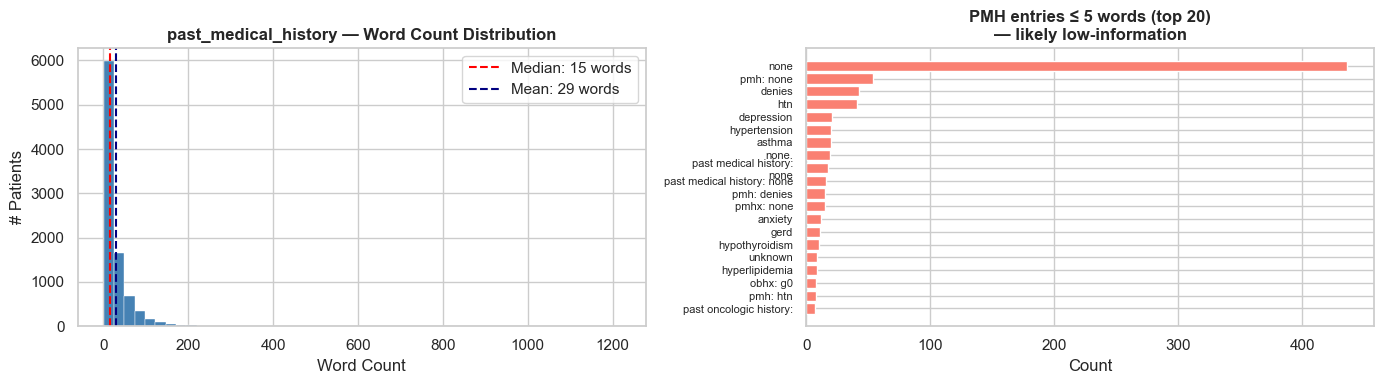


Word count stats — min: 1, median: 15, mean: 29, max: 1217
Entries ≤ 5 words   : 2417 (26.5%)

── Sample PMH values (non-null, >5 words) ──
  [1] Anemia Borderline cholesterol C. Diff Flatulence Health Maintenance Heart Murmur Hypertension Hypothyroidism Mitral Regurgitation Osteoporosis Pneumonia Sinusitis ___
  [2] 1. Sarcoidosis<comma> dx skin bx: intestinal & pulmonary involvement<comma> recurrent iritis 2. Inflammatory bowel disease; s/p ileo-hemicolectomy ___<comma> path +sarcoid 3. GERD. 4. Hyperlipidemia 5
  [3] PMH: DVT R pop v (___)<comma> asthma<comma> Rt pop artery thrombus with negative hypercoagulable workup
  [4] 1. Hypertension 2. Hypothyroidism<comma> status post partial thyroidectomy for multinodular goiter 3. Arthritis 4. Spinal stenosis 5. Chronic low back pain 6. Mitral valve prolapse 7. Irritable bowel 
  [5] - HIV - ? Schizoaffective disorder - Alcoholism - Psoriasis - Hypertension - Hepatitis B<comma> resolved per patient report - Peyronie's disease - Hyperlipi

In [29]:
# ── 6b  past_medical_history — EDA after extraction ─────────────────────────
# NOTE: Run Section 5 (merge) + Section 6 (extract) before this cell.

pmh = df["past_medical_history"]

# --- Null / empty analysis ---
null_count  = pmh.isna().sum()
empty_count = (pmh.fillna("").str.strip() == "").sum()
fake_nulls  = pmh.astype(str).str.strip().str.lower().isin(["nan", "none", "null"])

print(f"Total rows          : {len(pmh):,}")
print(f"True NaN            : {null_count}  ({null_count/len(pmh)*100:.1f}%)")
print(f"Empty string ('')   : {empty_count - null_count}")
print(f"String-encoded nulls: {fake_nulls.sum()}")
print(f"Non-null, non-empty : {(~pmh.isna() & (pmh.str.strip() != '')).sum():,}")

# --- Word count distribution ---
pmh_wc = pmh.dropna().apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(pmh_wc[pmh_wc > 0], bins=50, color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].axvline(pmh_wc.median(), color="red",  linestyle="--", linewidth=1.5,
                label=f"Median: {pmh_wc.median():.0f} words")
axes[0].axvline(pmh_wc.mean(),   color="navy", linestyle="--", linewidth=1.5,
                label=f"Mean: {pmh_wc.mean():.0f} words")
axes[0].set_title("past_medical_history — Word Count Distribution", fontweight="bold")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("# Patients")
axes[0].legend()

# Short PMH entries (≤5 words) — likely low-content: "None", "Denies", "N/A", etc.
short_pmh = pmh.dropna()[pmh_wc <= 5]
short_counts = short_pmh.str.strip().str.lower().value_counts().head(20)
axes[1].barh(short_counts.index[::-1], short_counts.values[::-1], color="salmon")
axes[1].set_title("PMH entries ≤ 5 words (top 20)\n— likely low-information", fontweight="bold")
axes[1].set_xlabel("Count")
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

print(f"\nWord count stats — min: {pmh_wc.min()}, median: {pmh_wc.median():.0f}, "
      f"mean: {pmh_wc.mean():.0f}, max: {pmh_wc.max()}")
print(f"Entries ≤ 5 words   : {(pmh_wc <= 5).sum()} ({(pmh_wc <= 5).mean()*100:.1f}%)")

# --- Sample values ---
print("\n── Sample PMH values (non-null, >5 words) ──")
samples = pmh.dropna()[pmh_wc > 5].head(5)
for i, val in enumerate(samples, 1):
    print(f"  [{i}] {str(val)[:200].replace(chr(10), ' ')}")


## Section 6 — Reorder Columns & Validate

Reorder to the canonical 22-column schema, then assert shape, column order, and stay_id uniqueness.

In [30]:
# Target column order — matches consolidated_dataset_PMH.csv schema exactly
TARGET_COLUMNS = [
    "stay_id",
    "subject_id",
    "hadm_id",
    "text",
    "HPI",
    "patient_info",
    "initial_vitals",
    "tests",
    "past_medication",
    "diagnosis",
    "primary_diagnosis",
    "secondary_diagnosis",
    "triage",
    "pain",
    "chiefcomplaint",
    "arrival_transport",
    "disposition",
    "icd_code",
    "icd_title",
    "icd_version",
    "specialty",
    "past_medical_history",
]

# Confirm all target columns exist in df before reordering
missing_cols = [c for c in TARGET_COLUMNS if c not in df.columns]
extra_cols   = [c for c in df.columns if c not in TARGET_COLUMNS]
if missing_cols:
    print(f"WARNING — columns in target schema but missing from df: {missing_cols}")
if extra_cols:
    print(f"INFO — extra columns in df not in target schema (will be dropped): {extra_cols}")

# Reorder (also implicitly drops any extra columns not in TARGET_COLUMNS)
df = df[TARGET_COLUMNS]

# --- Assertions ---
assert df.shape == (9149, 22), (
    f"Shape assertion failed: expected (9149, 22), got {df.shape}"
)
assert list(df.columns) == TARGET_COLUMNS, (
    f"Column order mismatch.\nExpected: {TARGET_COLUMNS}\nGot: {list(df.columns)}"
)
assert df["stay_id"].nunique() == 9149, (
    f"stay_id uniqueness failed: {df['stay_id'].nunique()} unique values (expected 9149)"
)

print(f"Validation passed. Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Validation passed. Shape: (9149, 22)
Columns: ['stay_id', 'subject_id', 'hadm_id', 'text', 'HPI', 'patient_info', 'initial_vitals', 'tests', 'past_medication', 'diagnosis', 'primary_diagnosis', 'secondary_diagnosis', 'triage', 'pain', 'chiefcomplaint', 'arrival_transport', 'disposition', 'icd_code', 'icd_title', 'icd_version', 'specialty', 'past_medical_history']


## Section 7 — Save Consolidated Dataset

Writes the final 22-column dataframe to `ed_triage_ai/data/consolidated_dataset_PMH_v2.csv`.  
This file is the input for `data_cleaning.ipynb`.

In [31]:
OUTPUT_KEY      = "Data_Output/consolidated_dataset_PMH_v2.csv"
OUTPUT_S3_URI   = f"s3://{S3_BUCKET}/{OUTPUT_KEY}"

# Write DataFrame to an in-memory buffer and upload to S3
buffer = io.BytesIO()
df.to_csv(buffer, index=False)
buffer.seek(0)

s3.put_object(
    Bucket=S3_BUCKET,
    Key=OUTPUT_KEY,
    Body=buffer.getvalue(),
    ContentType="text/csv",
)

print(f"Saved : {OUTPUT_S3_URI}")
print(f"Shape : {df.shape}")
print(f"Columns: {list(df.columns)}")


Saved : s3://ed-triage-capstone-group7/Data_Output/consolidated_dataset_PMH_v2.csv
Shape : (9149, 22)
Columns: ['stay_id', 'subject_id', 'hadm_id', 'text', 'HPI', 'patient_info', 'initial_vitals', 'tests', 'past_medication', 'diagnosis', 'primary_diagnosis', 'secondary_diagnosis', 'triage', 'pain', 'chiefcomplaint', 'arrival_transport', 'disposition', 'icd_code', 'icd_title', 'icd_version', 'specialty', 'past_medical_history']
